<a href="https://colab.research.google.com/github/VickyW2366/Shors-optimisations/blob/main/(Before-Optimisation)_QFT_with_3_Qubits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.8 MB/s eta 0:00:00
Circuit before QFT:
     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
c: 3/═════
          

Circuit with QFT:
     ┌───┐┌───┐                                           ┌─┐   
q_0: ┤ X ├┤ H ├─■────────■──────────────────────────────X─┤M├───
     └───┘└───┘ │P(π/2)  │       ┌───┐              ┌─┐ │ └╥┘   
q_1: ───────────■────────┼───────┤ H ├─■────────────┤M├─┼──╫────
     ┌───┐               │P(π/4) └───┘ │P(π/2) ┌───┐└╥┘ │  ║ ┌─┐
q_2: ┤ X ├───────────────■─────────────■───────┤ H ├─╫──X──╫─┤M├
     └───┘                                     └───┘ ║     ║ └╥┘
c: 3/════════════════════════════════════════════════╩═════╩══╩═
                              

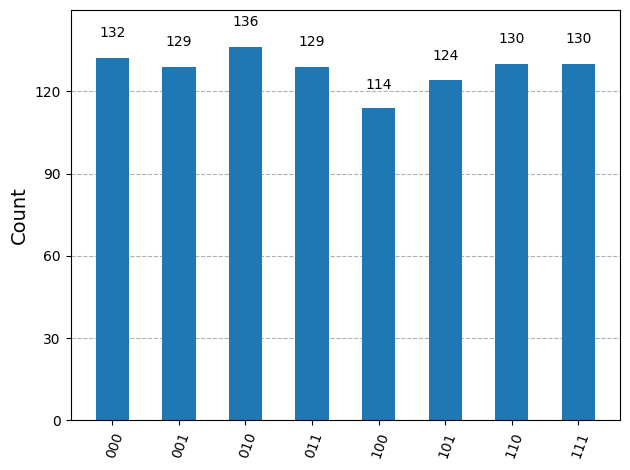

In [1]:
#!pip install qiskit  # Uncomment installations upon first time running
#!pip install qiskit-aer

import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np
import time

# Measures how long the  program takes to run
start_time = time.clock()

# Create circuit with 3 qubits
n = 3
qc = QuantumCircuit(n, n)

# Initial state: |5> (101 in binary)
# Prepare state |101> = |5>
qc.x(0)  # qubit 0 = 1
qc.x(2)  # qubit 2 = 1

print("Circuit before QFT:")
print(qc)

# Apply QFT
def qft_3qubit(circuit, n):
    """QFT optimized for 3 qubits"""
    # First qubit
    circuit.h(0)
    circuit.cp(np.pi/2, 1, 0)   # R2 with control on 1, target on 0
    circuit.cp(np.pi/4, 2, 0)   # R3 with control on 2, target on 0

    # Second qubit
    circuit.h(1)
    circuit.cp(np.pi/2, 2, 1)   # R2 with control on 2, target on 1

    # Third qubit
    circuit.h(2)

    # Swap order: 0 ↔ 2
    circuit.swap(0, 2)

# Apply QFT
qft_3qubit(qc, n)

# Measure
qc.measure(range(n), range(n))

print("\nCircuit with QFT:")
print(qc)

# Execute
backend = Aer.get_backend('qasm_simulator')

job = backend.run(qc, shots=1024)

result = job.result()
counts = result.get_counts()

print("\nMeasurement results:")
print(counts)

# Visualize
plot_histogram(counts)

print("Program took %s seconds to run" % (time.time() - start_time))